In [ ]:
#import necesary library

import pandas as pd

In [ ]:
df = pd.read_csv('/content/global_ecommerce_sales.csv')

In [ ]:
df.head()

,Transaction Date,Customer ID,Region,Product,Category,Price,Quantity,Discount (%),Total Revenue,Payment Method
0,2022-10-21,CUST_32167,Asia,Product_8109,Fashion,805.51,4,3.63,3105.08,Cash
1,2022-07-25,CUST_79483,Europe,Product_7873,Books,92.96,1,1.83,91.26,Cash
2,2023-08-24,CUST_97186,Europe,Product_9334,Home & Kitchen,700.87,3,21.86,1642.98,PayPal
3,2023-11-23,CUST_50953,Asia,Product_1364,Electronics,507.21,3,14.67,1298.41,Credit Card
4,2022-04-11,CUST_43293,Europe,Product_9899,Toys & Games,985.92,5,26.19,3638.54,PayPal


In [ ]:
df.shape

(191948, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191948 entries, 0 to 191947
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  191948 non-null  object 
 1   Customer ID       191948 non-null  object 
 2   Region            191948 non-null  object 
 3   Product           191948 non-null  object 
 4   Category          191948 non-null  object 
 5   Price             191948 non-null  float64
 6   Quantity          191948 non-null  int64  
 7   Discount (%)      191948 non-null  float64
 8   Total Revenue     191948 non-null  float64
 9   Payment Method    191948 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 14.6+ MB


In [ ]:
df.isnull().sum()

,0
Transaction Date,0
Customer ID,0
Region,0
Product,0
Category,0
Price,0
Quantity,0
Discount (%),0
Total Revenue,0
Payment Method,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Find rows containing at least one empty/blank cell
df[df.astype(str).apply(lambda x: x.str.strip() == '').any(axis=1)]

,Transaction Date,Customer ID,Region,Product,Category,Price,Quantity,Discount (%),Total Revenue,Payment Method


In [ ]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [ ]:
df.dtypes

,0
Transaction Date,datetime64[ns]
Customer ID,object
Region,object
Product,object
Category,object
Price,float64
Quantity,int64
Discount (%),float64
Total Revenue,float64
Payment Method,object


In [ ]:
# Check number of unique customers
df['Customer ID'].nunique()

84658

In [ ]:
# Count transactions for each customer
customer_counts = df['Customer ID'].value_counts()

# Number of customers with more than one transaction
(customer_counts > 1).sum()

np.int64(56990)

In [ ]:
# Distribution of transactions per customer
customer_counts.value_counts().sort_index()

,count
count,
1,27668
2,26483
3,17419
4,8346
5,3295
6,1051
7,302
8,74
9,16


In [ ]:
# Check numerical values
df.describe()

,Transaction Date,Price,Quantity,Discount (%),Total Revenue
count,191948,191948.000000,191948.000000,191948.000000,191948.000000
mean,2022-12-31 14:30:37.547669248,502.938573,3.002756,14.964822,1282.973802
min,2022-01-01 00:00:00,5.010000,1.000000,0.000000,3.590000
25%,2022-07-02 00:00:00,255.077500,2.000000,7.440000,470.880000
50%,2022-12-31 00:00:00,502.610000,3.000000,14.970000,992.970000
75%,2023-07-02 00:00:00,750.385000,4.000000,22.470000,1892.280000
max,2024-01-01 00:00:00,999.990000,5.000000,30.000000,4988.910000
std,NaN,286.811439,1.415807,8.671819,1022.579194


In [ ]:
# Find each customer's first transaction date
first_purchase = (
    df.groupby('Customer ID')['Transaction Date']
      .min()
      .reset_index()
)

first_purchase.head()

,Customer ID,Transaction Date
0,CUST_10000,2022-01-30
1,CUST_10001,2022-12-12
2,CUST_10002,2022-11-16
3,CUST_10003,2022-07-06
4,CUST_10004,2022-12-04


In [ ]:
# Create cohort month from first purchase date
first_purchase['CohortMonth'] = (
    first_purchase['Transaction Date'].dt.to_period('M')
)

first_purchase.head()

,Customer ID,Transaction Date,CohortMonth
0,CUST_10000,2022-01-30,2022-01
1,CUST_10001,2022-12-12,2022-12
2,CUST_10002,2022-11-16,2022-11
3,CUST_10003,2022-07-06,2022-07
4,CUST_10004,2022-12-04,2022-12


In [ ]:
# Rename first transaction date for clarity
first_purchase = first_purchase.rename(
    columns={'Transaction Date': 'FirstPurchaseDate'}
)

first_purchase.head()

,Customer ID,FirstPurchaseDate,CohortMonth
0,CUST_10000,2022-01-30,2022-01
1,CUST_10001,2022-12-12,2022-12
2,CUST_10002,2022-11-16,2022-11
3,CUST_10003,2022-07-06,2022-07
4,CUST_10004,2022-12-04,2022-12


In [ ]:
# Add first purchase date and cohort month to each transaction
df = df.merge(
    first_purchase,
    on='Customer ID',
    how='left'
)

df.head()

,Transaction Date,Customer ID,Region,Product,Category,Price,Quantity,Discount (%),Total Revenue,Payment Method,FirstPurchaseDate,CohortMonth
0,2022-10-21,CUST_32167,Asia,Product_8109,Fashion,805.51,4,3.63,3105.08,Cash,2022-10-21,2022-10
1,2022-07-25,CUST_79483,Europe,Product_7873,Books,92.96,1,1.83,91.26,Cash,2022-07-25,2022-07
2,2023-08-24,CUST_97186,Europe,Product_9334,Home & Kitchen,700.87,3,21.86,1642.98,PayPal,2023-04-06,2023-04
3,2023-11-23,CUST_50953,Asia,Product_1364,Electronics,507.21,3,14.67,1298.41,Credit Card,2023-06-24,2023-06
4,2022-04-11,CUST_43293,Europe,Product_9899,Toys & Games,985.92,5,26.19,3638.54,PayPal,2022-04-11,2022-04


In [ ]:
# Create transaction month for each purchase
df['TransactionMonth'] = df['Transaction Date'].dt.to_period('M')

df[['Customer ID', 'Transaction Date', 'CohortMonth', 'TransactionMonth']].head()

,Customer ID,Transaction Date,CohortMonth,TransactionMonth
0,CUST_32167,2022-10-21,2022-10,2022-10
1,CUST_79483,2022-07-25,2022-07,2022-07
2,CUST_97186,2023-08-24,2023-04,2023-08
3,CUST_50953,2023-11-23,2023-06,2023-11
4,CUST_43293,2022-04-11,2022-04,2022-04


In [ ]:
# Show all transactions for one customer
df[df['Customer ID'] == 'CUST_97186'][
    ['Customer ID', 'Transaction Date', 'FirstPurchaseDate',
     'CohortMonth', 'TransactionMonth']
].sort_values('Transaction Date')

,Customer ID,Transaction Date,FirstPurchaseDate,CohortMonth,TransactionMonth
8542,CUST_97186,2023-04-06,2023-04-06,2023-04,2023-04
181268,CUST_97186,2023-06-26,2023-04-06,2023-04,2023-06
2,CUST_97186,2023-08-24,2023-04-06,2023-04,2023-08


In [ ]:
# Calculate number of months since customer's first purchase
df['CohortIndex'] = (
    (df['TransactionMonth'].dt.year - df['CohortMonth'].dt.year) * 12
    + (df['TransactionMonth'].dt.month - df['CohortMonth'].dt.month)
)

df[['Customer ID', 'CohortMonth', 'TransactionMonth', 'CohortIndex']].head()

,Customer ID,CohortMonth,TransactionMonth,CohortIndex
0,CUST_32167,2022-10,2022-10,0
1,CUST_79483,2022-07,2022-07,0
2,CUST_97186,2023-04,2023-08,4
3,CUST_50953,2023-06,2023-11,5
4,CUST_43293,2022-04,2022-04,0


In [ ]:
# Check cohort index for one repeat customer
df[df['Customer ID'] == 'CUST_97186'][
    ['Customer ID', 'Transaction Date', 'CohortMonth',
     'TransactionMonth', 'CohortIndex']
].sort_values('Transaction Date')

,Customer ID,Transaction Date,CohortMonth,TransactionMonth,CohortIndex
8542,CUST_97186,2023-04-06,2023-04,2023-04,0
181268,CUST_97186,2023-06-26,2023-04,2023-06,2
2,CUST_97186,2023-08-24,2023-04,2023-08,4


In [ ]:
# Count unique customers by cohort and cohort index
cohort_data = (
    df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID']
      .nunique()
      .reset_index(name='CustomerCount')
)

cohort_data.head(10)

,CohortMonth,CohortIndex,CustomerCount
0,2022-01,0,7858
1,2022-01,1,556
2,2022-01,2,645
3,2022-01,3,621
4,2022-01,4,603
5,2022-01,5,630
6,2022-01,6,594
7,2022-01,7,618
8,2022-01,8,638
9,2022-01,9,614


In [29]:
# Create cohort customer count table
cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerCount'
)

cohort_counts

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2022-01,7858.0,556.0,645.0,621.0,603.0,630.0,594.0,618.0,638.0,614.0,...,598.0,647.0,571.0,651.0,623.0,594.0,628.0,655.0,679.0,27.0
2022-02,6573.0,521.0,534.0,541.0,501.0,520.0,539.0,482.0,512.0,528.0,...,534.0,485.0,501.0,503.0,500.0,479.0,507.0,520.0,16.0,NaN
2022-03,6642.0,494.0,509.0,482.0,520.0,492.0,509.0,500.0,498.0,514.0,...,512.0,528.0,504.0,539.0,508.0,459.0,555.0,20.0,NaN,NaN
2022-04,5941.0,443.0,423.0,464.0,491.0,490.0,515.0,463.0,484.0,483.0,...,446.0,477.0,440.0,443.0,458.0,494.0,16.0,NaN,NaN,NaN
2022-05,5633.0,423.0,468.0,468.0,399.0,450.0,460.0,450.0,431.0,404.0,...,442.0,449.0,460.0,395.0,468.0,11.0,NaN,NaN,NaN,NaN
2022-06,5079.0,395.0,347.0,432.0,406.0,368.0,440.0,419.0,393.0,388.0,...,381.0,407.0,389.0,397.0,13.0,NaN,NaN,NaN,NaN,NaN
2022-07,4934.0,370.0,390.0,403.0,380.0,413.0,362.0,369.0,402.0,371.0,...,419.0,365.0,381.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN
2022-08,4361.0,327.0,334.0,341.0,340.0,353.0,305.0,352.0,315.0,332.0,...,336.0,301.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,4101.0,341.0,305.0,320.0,317.0,313.0,311.0,329.0,347.0,336.0,...,283.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Get the original size of each cohort (Month 0)
cohort_sizes = cohort_counts[0]

cohort_sizes.head()

,0
CohortMonth,
2022-01,7858.0
2022-02,6573.0
2022-03,6642.0
2022-04,5941.0
2022-05,5633.0


In [31]:
# Calculate customer retention rate
retention_rate = cohort_counts.divide(cohort_sizes, axis=0)

retention_rate.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2022-01,1.0,0.070756,0.082082,0.079028,0.076737,0.080173,0.075592,0.078646,0.081191,0.078137,...,0.076101,0.082336,0.072665,0.082846,0.079282,0.075592,0.079919,0.083355,0.086409,0.003436
2022-02,1.0,0.079264,0.081241,0.082306,0.076221,0.079112,0.082002,0.073330,0.077894,0.080329,...,0.081241,0.073787,0.076221,0.076525,0.076069,0.072874,0.077134,0.079112,0.002434,NaN
2022-03,1.0,0.074375,0.076634,0.072569,0.078290,0.074074,0.076634,0.075279,0.074977,0.077386,...,0.077085,0.079494,0.075881,0.081150,0.076483,0.069106,0.083559,0.003011,NaN,NaN
2022-04,1.0,0.074567,0.071200,0.078101,0.082646,0.082478,0.086686,0.077933,0.081468,0.081299,...,0.075072,0.080290,0.074062,0.074567,0.077091,0.083151,0.002693,NaN,NaN,NaN
2022-05,1.0,0.075093,0.083082,0.083082,0.070833,0.079886,0.081662,0.079886,0.076513,0.071720,...,0.078466,0.079709,0.081662,0.070122,0.083082,0.001953,NaN,NaN,NaN,NaN


In [32]:
# Display retention rates as percentages
retention_percent = (retention_rate * 100).round(2)

retention_percent.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2022-01,100.0,7.08,8.21,7.90,7.67,8.02,7.56,7.86,8.12,7.81,...,7.61,8.23,7.27,8.28,7.93,7.56,7.99,8.34,8.64,0.34
2022-02,100.0,7.93,8.12,8.23,7.62,7.91,8.20,7.33,7.79,8.03,...,8.12,7.38,7.62,7.65,7.61,7.29,7.71,7.91,0.24,NaN
2022-03,100.0,7.44,7.66,7.26,7.83,7.41,7.66,7.53,7.50,7.74,...,7.71,7.95,7.59,8.12,7.65,6.91,8.36,0.30,NaN,NaN
2022-04,100.0,7.46,7.12,7.81,8.26,8.25,8.67,7.79,8.15,8.13,...,7.51,8.03,7.41,7.46,7.71,8.32,0.27,NaN,NaN,NaN
2022-05,100.0,7.51,8.31,8.31,7.08,7.99,8.17,7.99,7.65,7.17,...,7.85,7.97,8.17,7.01,8.31,0.20,NaN,NaN,NaN,NaN


In [33]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

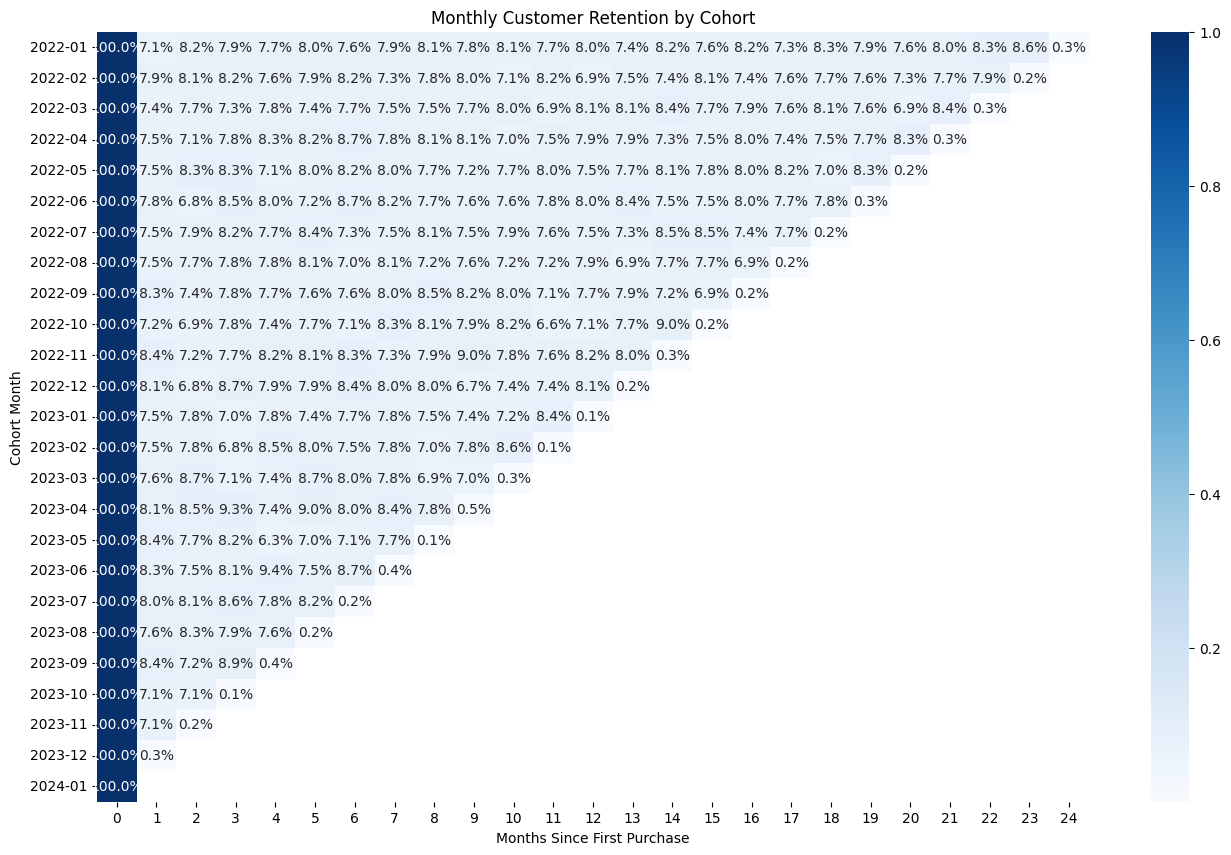

In [34]:
# Create cohort retention heatmap
plt.figure(figsize=(16, 10))

sns.heatmap(
    retention_rate,
    annot=True,
    fmt='.1%',
    cmap='Blues'
)

plt.title('Monthly Customer Retention by Cohort')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.show()

In [35]:
# Exclude incomplete January 2024 data
df_analysis = df[df['Transaction Date'] < '2024-01-01'].copy()

df_analysis.shape

(191702, 14)

In [36]:
# Verify analysis date range
print("Start date:", df_analysis['Transaction Date'].min())
print("End date:", df_analysis['Transaction Date'].max())

Start date: 2022-01-01 00:00:00
End date: 2023-12-31 00:00:00


In [37]:
# Rebuild cohort customer counts using complete months only
cohort_data = (
    df_analysis.groupby(['CohortMonth', 'CohortIndex'])['Customer ID']
    .nunique()
    .reset_index(name='CustomerCount')
)

# Create cohort count table
cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerCount'
)

# Get original cohort sizes
cohort_sizes = cohort_counts[0]

# Calculate retention rate
retention_rate = cohort_counts.divide(cohort_sizes, axis=0)

# Convert to percentage for viewing
retention_percent = (retention_rate * 100).round(2)

retention_percent

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2022-01,100.0,7.08,8.21,7.90,7.67,8.02,7.56,7.86,8.12,7.81,...,8.21,7.61,8.23,7.27,8.28,7.93,7.56,7.99,8.34,8.64
2022-02,100.0,7.93,8.12,8.23,7.62,7.91,8.20,7.33,7.79,8.03,...,7.38,8.12,7.38,7.62,7.65,7.61,7.29,7.71,7.91,NaN
2022-03,100.0,7.44,7.66,7.26,7.83,7.41,7.66,7.53,7.50,7.74,...,8.42,7.71,7.95,7.59,8.12,7.65,6.91,8.36,NaN,NaN
2022-04,100.0,7.46,7.12,7.81,8.26,8.25,8.67,7.79,8.15,8.13,...,7.31,7.51,8.03,7.41,7.46,7.71,8.32,NaN,NaN,NaN
2022-05,100.0,7.51,8.31,8.31,7.08,7.99,8.17,7.99,7.65,7.17,...,8.10,7.85,7.97,8.17,7.01,8.31,NaN,NaN,NaN,NaN
2022-06,100.0,7.78,6.83,8.51,7.99,7.25,8.66,8.25,7.74,7.64,...,7.46,7.50,8.01,7.66,7.82,NaN,NaN,NaN,NaN,NaN
2022-07,100.0,7.50,7.90,8.17,7.70,8.37,7.34,7.48,8.15,7.52,...,8.47,8.49,7.40,7.72,NaN,NaN,NaN,NaN,NaN,NaN
2022-08,100.0,7.50,7.66,7.82,7.80,8.09,6.99,8.07,7.22,7.61,...,7.70,7.70,6.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,100.0,8.32,7.44,7.80,7.73,7.63,7.58,8.02,8.46,8.19,...,7.19,6.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


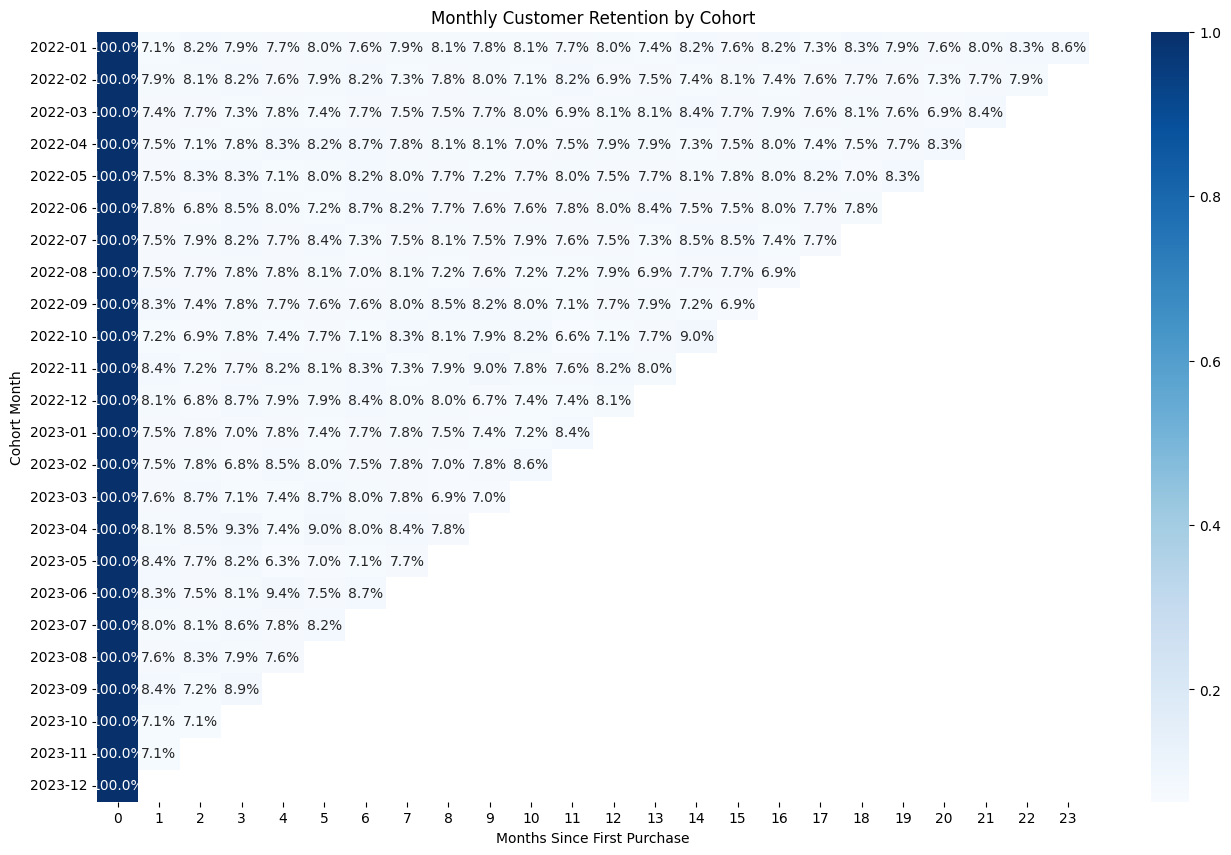

In [38]:
# Updated retention heatmap using complete months only
plt.figure(figsize=(16, 10))

sns.heatmap(
    retention_rate,
    annot=True,
    fmt='.1%',
    cmap='Blues'
)

plt.title('Monthly Customer Retention by Cohort')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.show()

In [39]:
# Calculate total revenue by cohort and cohort index
cohort_revenue = (
    df_analysis.groupby(['CohortMonth', 'CohortIndex'])['Total Revenue']
    .sum()
    .reset_index()
)

cohort_revenue.head(10)

,CohortMonth,CohortIndex,Total Revenue
0,2022-01,0,10354668.27
1,2022-01,1,713530.98
2,2022-01,2,862204.85
3,2022-01,3,839562.06
4,2022-01,4,824803.09
5,2022-01,5,858484.40
6,2022-01,6,789502.81
7,2022-01,7,806099.48
8,2022-01,8,857740.59
9,2022-01,9,798892.91


In [40]:
# Create cohort revenue table
revenue_matrix = cohort_revenue.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Total Revenue'
)

revenue_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2022-01,10354668.27,713530.98,862204.85,839562.06,824803.09,858484.40,789502.81,806099.48,857740.59,798892.91,...,861846.43,801769.02,837884.87,804249.70,856407.90,808154.82,794599.67,855678.52,840928.02,854112.07
2022-02,8747106.96,717313.17,715376.83,734675.71,701033.91,672759.30,707827.98,656059.04,708676.40,737409.99,...,650571.90,724068.25,658051.05,673841.71,704375.64,660074.23,662318.91,658758.41,725129.15,NaN
2022-03,8918716.72,661285.30,671116.43,635816.94,694255.12,662511.51,691251.32,669391.52,678728.27,697331.13,...,686141.83,699046.64,704556.53,646463.28,711176.02,731676.00,655071.74,723615.74,NaN,NaN
2022-04,8051837.67,635203.70,600579.00,656034.88,657845.46,668393.65,701398.53,606579.99,664865.09,661859.78,...,594972.09,601537.07,654414.66,595161.57,583938.11,653365.91,649489.61,NaN,NaN,NaN
2022-05,7440507.77,562737.67,647693.24,622837.56,525339.08,642265.64,607263.47,641357.60,544840.48,541870.49,...,571174.17,601608.57,599933.21,641289.44,490924.74,656339.35,NaN,NaN,NaN,NaN
2022-06,6818005.56,582649.47,476095.73,562037.72,555024.79,482033.01,580414.34,573100.83,505195.93,524763.16,...,509546.19,504391.49,502894.70,517986.36,549291.29,NaN,NaN,NaN,NaN,NaN
2022-07,6716714.36,503160.40,492311.08,508373.07,499990.71,529202.05,449971.27,477854.21,523622.93,507447.78,...,564900.29,544686.27,481675.46,504098.80,NaN,NaN,NaN,NaN,NaN,NaN
2022-08,5809480.69,430869.97,444969.67,429028.02,455753.72,466678.61,406443.08,457776.65,434647.99,449767.83,...,451157.96,412819.17,383601.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,5508430.04,483258.91,414783.15,411029.70,428080.10,414132.41,425428.84,421086.68,462270.67,421555.68,...,406930.93,341752.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# Calculate revenue per active customer
revenue_per_customer = revenue_matrix.divide(cohort_counts)

revenue_per_customer.round(2)

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2022-01,1317.72,1283.33,1336.75,1351.95,1367.83,1362.67,1329.13,1304.37,1344.42,1301.13,...,1336.20,1340.75,1295.03,1408.49,1315.53,1297.20,1337.71,1362.55,1283.86,1257.9
2022-02,1330.76,1376.80,1339.66,1358.00,1399.27,1293.77,1313.22,1361.12,1384.13,1396.61,...,1341.39,1355.93,1356.81,1344.99,1400.35,1320.15,1382.71,1299.33,1394.48,NaN
2022-03,1342.78,1338.63,1318.50,1319.12,1335.11,1346.57,1358.06,1338.78,1362.91,1356.68,...,1227.45,1365.33,1334.39,1282.67,1319.44,1440.31,1427.17,1303.81,NaN,NaN
2022-04,1355.30,1433.87,1419.81,1413.87,1339.81,1364.07,1361.94,1310.11,1373.69,1370.31,...,1370.90,1348.74,1371.94,1352.64,1318.14,1426.56,1314.76,NaN,NaN,NaN
2022-05,1320.88,1330.35,1383.96,1330.85,1316.64,1427.26,1320.14,1425.24,1264.13,1341.26,...,1252.57,1361.11,1336.15,1394.11,1242.85,1402.43,NaN,NaN,NaN,NaN
2022-06,1342.39,1475.06,1372.03,1301.01,1367.06,1309.87,1319.12,1367.78,1285.49,1352.48,...,1344.45,1323.86,1235.61,1331.58,1383.61,NaN,NaN,NaN,NaN,NaN
2022-07,1361.31,1359.89,1262.34,1261.47,1315.77,1281.36,1243.01,1295.00,1302.54,1367.78,...,1351.44,1299.97,1319.66,1323.09,NaN,NaN,NaN,NaN,NaN,NaN
2022-08,1332.14,1317.65,1332.24,1258.15,1340.45,1322.04,1332.60,1300.50,1379.83,1354.72,...,1342.73,1228.63,1274.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,1343.19,1417.18,1359.94,1284.47,1350.41,1323.11,1367.94,1279.90,1332.19,1254.63,...,1379.43,1207.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# Export processed cohort dataset for Tableau
df_analysis.to_csv(
    'cohort_analysis_tableau.csv',
    index=False
)

In [43]:
# Download CSV file
from google.colab import files

files.download('cohort_analysis_tableau.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>